# Calculate CPM 

In [3]:
suppressPackageStartupMessages({
    library(Seurat)
    library(SeuratWrappers)
    library(patchwork)
    library(ggplot2)
    library(repr)
    library(gridExtra)
    library(edgeR)
    library(SingleCellExperiment)
    library(Matrix)
    library(scran)
    library(tidyverse)
    library(ggrepel)
    library(scater)
})
options(future.globals.maxSize = 1e9)
options(Seurat.object.assay.version = "v5")
options(ggrepel.max.overlaps = Inf)

Loading Seurat v5 beta version 
To maintain compatibility with previous workflows, new Seurat objects will use the previous object structure by default
To use new Seurat v5 assays: Please run: options(Seurat.object.assay.version = 'v5')

Warning message in system("timedatectl", intern = TRUE):
“running command 'timedatectl' had status 1”


In [4]:
data.dir <- '/mouseAD/processed_data/'
all.paths <- list.files('data/Celltype_Seurat_Objects/')
splitted.objects <- vector(mode = 'list', length = length(all.paths))
names(splitted.objects) <- sapply(strsplit(all.paths, "[.]"), `[`, 1)
for (path in all.paths) {
    celltype <- strsplit(path, split = '[.]')[[1]][1]
    print(celltype)
    splitted.objects[[celltype]] <- readRDS(file.path('data//Celltype_Seurat_Objects', path))
}

[1] "Astro"
[1] "CA1"
[1] "CA2"
[1] "CA3"
[1] "Cajal-Retzius"
[1] "Chandelier"
[1] "Choroid-plexus"
[1] "DG"
[1] "Endo"
[1] "IOL"
[1] "Lamp5"
[1] "Meis2"
[1] "Microglia"
[1] "NB"
[1] "Oligo"
[1] "OPC"
[1] "Pvalb"
[1] "PVM"
[1] "RGL"
[1] "SMC-Peri"
[1] "Sncg"
[1] "Sst"
[1] "SUB_1"
[1] "SUB_2"
[1] "SUB_3"
[1] "SUB-ProS"
[1] "Vip"
[1] "VLMC"


In [5]:
raw.counts <- vector(mode = 'list', length = length(all.paths))
names(raw.counts) <- sapply(strsplit(all.paths, "[.]"), `[`, 1)
log2.cpm <- vector(mode = 'list', length = length(all.paths))
names(log2.cpm) <- sapply(strsplit(all.paths, "[.]"), `[`, 1)

In [6]:
for (name in names(splitted.objects)) {
    print(name)
    curr.object <- splitted.objects[[name]]
    curr.counts <- LayerData(curr.object, layer = c("counts"))
    curr.meta <- curr.object@meta.data
    curr.sce <- SingleCellExperiment(assays = list(counts = curr.counts), colData = curr.meta)
    
    curr.aggr <- aggregateAcrossCells(curr.sce, rep("CPM", ncol(curr.counts)), store.number = "group.size")
    curr.cpm <- calculateCPM(curr.aggr)
    
    raw.counts[[name]] <- curr.aggr
    log2.cpm[[name]] <- log2(curr.cpm + 1)
    
    output.file <- file.path("data/CPM_no_grouping/", paste0(name, ".cpm.tsv"))
    write.table(curr.cpm, output.file, col.names = FALSE, row.names = TRUE, quote = FALSE, sep = "\t")
}

[1] "Astro"
[1] "CA1"
[1] "CA2"
[1] "CA3"
[1] "Cajal-Retzius"
[1] "Chandelier"
[1] "Choroid-plexus"
[1] "DG"
[1] "Endo"
[1] "IOL"
[1] "Lamp5"
[1] "Meis2"
[1] "Microglia"
[1] "NB"
[1] "Oligo"
[1] "OPC"
[1] "Pvalb"
[1] "PVM"
[1] "RGL"
[1] "SMC-Peri"
[1] "Sncg"
[1] "Sst"
[1] "SUB_1"
[1] "SUB_2"
[1] "SUB_3"
[1] "SUB-ProS"
[1] "Vip"
[1] "VLMC"


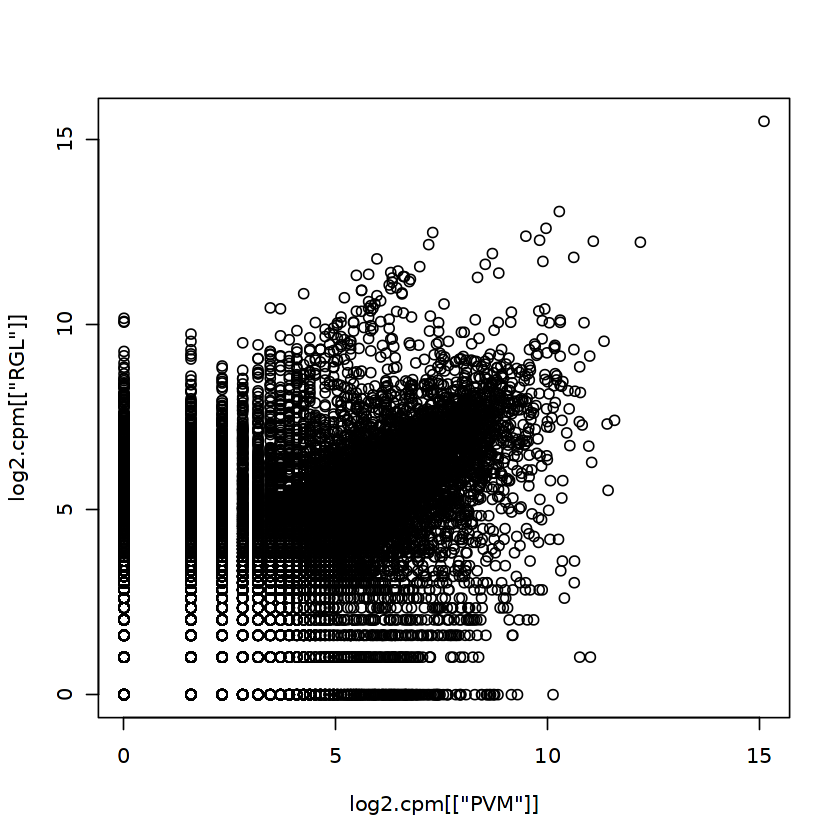

In [7]:
plot(log2.cpm[["PVM"]], log2.cpm[["RGL"]])